<a href="https://colab.research.google.com/github/HunterTzou/DATA_201_SPRING_2026/blob/main/Project%201/%20Tzou_Hunter_DATA201_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Montgomery County HHS Food Inspection Analysis
**Name:** Hunter Tzou  
**Course:** DATA 201  
**Submission Date:**

---
## 1. Introduction

*Write 1–2 paragraphs here covering:*
- *Dataset origin*
- *Population of interest*
- *Data collection method and limitations*
- *Ethical or bias concerns*

This dataset was retrieved from the Montgomery County Open Data Portal and originates from the Health & Human Services Licensure and Regulatory Services Division. Data is collected by inspectors in the field during food safety inspections at establishments where food is prepared and sold, and is updated automatically by the county's database platform.

According to an inspector interviewed as part of this project, data is entered into the county's system in real time during each inspection. One important structural note is that the dataset is organized at the checklist-item level — each inspection event generates approximately 104 rows, one per compliance criterion, which has direct implications for how the data must be wrangled. I also identified several data quality concerns: (1) there are no raw quantitative measurements — metrics like hot holding temperature are recorded only as In Compliance or Not In Compliance rather than numeric values; (2) there appear to be a substantial number of duplicate records; and (3) inspection numbers do not appear to be uniquely tied to individual registration numbers. These issues complicate basic counts like unique inspections or active establishments. I am working with county officials to clarify these ambiguities and am confident the dataset is suitable for the analyses conducted here.

Regarding bias and ethical concerns, inspection frequency may not be uniform across zip codes or business types — higher-risk establishments may be inspected more often, which could skew geographic comparisons. Additionally, since compliance is recorded categorically rather than as continuous measurements, nuanced differences in food safety performance may not be fully captured.

<br>

**Citation (ACM style):**

> Montgomery County Department of Health and Human Services. 2024. HHS Food Inspection Data from July 2024 and Onward. Montgomery County Open Data Portal. https://data.montgomerycountymd.gov/Health-and-Human-Services/HHS-Food-Inspection-Data-from-July-2024-and-onward/dkrp-gr48 (Accessed March 28, 2026).

---
## 2. Dataset Structure

In [57]:
# Computation & Exploration
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

#Geolocation
import folium
import ast

# Query from databases and access folder systems
import requests
import os
import requests
import geopandas as gpd

In [63]:
# Base raw URL for your GitHub repo - update with your actual path
BASE_URL =  "https://raw.githubusercontent.com/HunterTzou/DATA_201_SPRING_2026/main/Project%201/zipcodes/ZIPCODES"

# Download all required shapefile components
for ext in ['.shp', '.shx', '.dbf', '.prj']:
    url = BASE_URL + ext
    r = requests.get(url)
    with open(f'/tmp/ZIPCODES{ext}', 'wb') as f:
        f.write(r.content)
    print(f"Downloaded {ext}")

# Read with geopandas
import geopandas as gpd
zip_boundaries = gpd.read_file('/tmp/ZIPCODES.shp')
print(zip_boundaries.columns.tolist())
print(zip_boundaries.head())

Downloaded .shp
Downloaded .shx
Downloaded .dbf
Downloaded .prj
['ZIPCODE', 'MAIL_CITY', 'Shape_Leng', 'Shape_Area', 'geometry']
   ZIPCODE   MAIL_CITY    Shape_Leng    Shape_Area  \
0    20812   GLEN ECHO  14504.506513  9.810937e+06   
1    20816    BETHESDA  58716.124845  1.175655e+08   
2    20818  CABIN JOHN  31103.235156  3.599683e+07   
3    20894    BETHESDA   1298.401522  2.547457e+04   
4    20892    BETHESDA    140.742936  7.448763e+02   

                                            geometry  
0  POLYGON ((1271667.25 475296.156, 1271713.875 4...  
1  MULTIPOLYGON (((1272794.375 474255.781, 127273...  
2  POLYGON ((1267249.112 480102.674, 1267252.368 ...  
3  POLYGON ((1284968.166 483332.695, 1284976.979 ...  
4  POLYGON ((1284917.844 483898.594, 1284926.215 ...  


In [4]:
# --- Imports and Data Loading ---
# Load the dataset from the Socrata API (paginated)

# To set your token in an environment variable: in your terminal run -> export SOCRATA_TOKEN="your_token_here"

APP_TOKEN = os.getenv("SOCRATA_TOKEN")  # Returns None if not set — that's fine!

BASE_URL = "https://data.montgomerycountymd.gov/resource/dkrp-gr48.json"
LIMIT = 50000
all_records = []
offset = 0

print("Fetching data...")
while True:
    params = {
        "$limit": LIMIT,
        "$offset": offset,
    }

    # Only add token to request if it's available
    if APP_TOKEN:
        params["$$app_token"] = APP_TOKEN

    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    batch = response.json()

    if not batch:
        break

    all_records.extend(batch)
    offset += len(batch)
    print(f"  Fetched {offset:,} rows so far...")

    if len(batch) < LIMIT:
        break

# Build the DataFrame
df = pd.DataFrame(all_records)
print(f"\nRaw row count: {len(df):,}")

# Parse the location dictionaries

def parse_location(loc):
    """Parses a stringified GeoJSON Point dict -> (lat, lon) or (None, None)."""
    try:
        point = ast.literal_eval(str(loc))          # safely parse the stringified dict
        lon, lat = point['coordinates']              # GeoJSON is [lon, lat] order
        return round(lat, 5), round(lon, 5)
    except Exception:
        return None, None

Fetching data...
  Fetched 50,000 rows so far...
  Fetched 100,000 rows so far...
  Fetched 150,000 rows so far...
  Fetched 200,000 rows so far...
  Fetched 250,000 rows so far...
  Fetched 300,000 rows so far...
  Fetched 350,000 rows so far...
  Fetched 400,000 rows so far...
  Fetched 450,000 rows so far...
  Fetched 500,000 rows so far...
  Fetched 550,000 rows so far...
  Fetched 600,000 rows so far...
  Fetched 650,000 rows so far...
  Fetched 700,000 rows so far...
  Fetched 750,000 rows so far...
  Fetched 800,000 rows so far...
  Fetched 850,000 rows so far...
  Fetched 900,000 rows so far...
  Fetched 950,000 rows so far...
  Fetched 1,000,000 rows so far...
  Fetched 1,050,000 rows so far...
  Fetched 1,100,000 rows so far...
  Fetched 1,127,531 rows so far...

Raw row count: 1,127,531


In [5]:
# --- Raw Dataset Size ---
# Print number of rows and columns

rows_cols_tuple = df.shape
print(f"DataFrame shape (rows, columns): {rows_cols_tuple}")


DataFrame shape (rows, columns): (1127531, 30)


In [6]:
# DEDUPLICATE DATA

# There are a significant number of duplicates, which I have confirmed by my own count using
# Apply location parser and drop the original dict column

df[['latitude', 'longitude']] = df['location'].apply(
    lambda x: pd.Series(parse_location(x))
)

df = df.drop(columns=['location'])

print(f"Duplicate rows: {df.duplicated().sum():,}")

## Drop the Duplicates

df_clean = df.drop_duplicates().copy()
print(f"After dedup: {len(df_clean):,} rows")

print(df_clean.dtypes)

Duplicate rows: 1,110,965
After dedup: 16,566 rows
registration_number                     object
inspection_number                       object
business_name                           object
owner                                   object
address                                 object
city                                    object
state                                   object
zip                                     object
business_type                           object
business_subtype                        object
inspection_type                         object
inspection_start_date                   object
status                                  object
food_from_approved_source               object
food_protected_from_contamination       object
workers_restricted                      object
proper_hand_washing                     object
cooling_time_and_temperature            object
cold_holding_temperature                object
hot_holding_temperature                 object
cooking_t

In [7]:
df_clean.head()

,registration_number,inspection_number,business_name,owner,address,city,state,zip,business_type,business_subtype,...,reheating_time_and_temperature,hot_and_cold_running_water_provided,proper_sewage_disposal,toxic_substances_and_pesticides,rodents_and_insects,nutritional_labeling,trans_fat_ban,nosmoking_sign_posted,latitude,longitude
0,48593,26-2376,"CORI-COCO FRUITS & SHAVED ICE, LLC",CORI-COCO FRUITS & SHAVED ICE,17006 DOWNING ST,GAITHERSBURG,MD,20877,Food Service Facility,Food License-Mobile Food-New-Moderate,...,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,39.13512,-77.20839
1,54142,26-2352,DUNKIN' & BASKIN-ROBBINS,WHITE OAK DONUTS LLC,11140 NEW HAMPSHIRE AVE,Silver Spring,MD,20904,Food Service Facility,Food Service Facility License-Moderate,...,Not Applicable,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,39.03777,-76.99008
2,54453,26-2373,MARIAN ASSISTED LIVING-DOM,VICTORY HOUSING INC,19109 GEORGIA AVE,BROOKEVILLE,MD,20833,Food Service Facility,Food Service Facility License-For Profit-Priva...,...,Not Observed,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,39.17003,-77.05953
3,54531,26-2366,WODER ETHIOPIAN CARRYOUT/RESTAURANT,AWAY CORP.,7845 EASTERN AVE.,SILVER SPRING,MD,20910,Food Service Facility,Food Service Facility License-Moderate,...,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,38.98541,-77.02767
4,55016,26-2358,MOBY DICK NORTH BETHESDA,MOBY DICK NORTH BETHESDA LLC,11431-A ROCKVILLE PIKE,Rockville,MD,20852,Food Service Facility,Food Service Facility License-High,...,Not Observed,Not In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,In Compliance,39.04433,-77.11099


In [8]:
df_clean.isna().sum()

,0
registration_number,94
inspection_number,0
business_name,0
owner,21
address,0
city,0
state,0
zip,0
business_type,0
business_subtype,0


In [9]:
# Creating a unique key to distinguish each entity from one another and establish a group of entities.

# I was going to use the lat and longitude,  but then I noticed that there were 103 rows from the deduplicated dataset which have missing values in those colummns
# So, I have ran the following check to see what we can learn about the affected rows


missing_geo = df_clean[df_clean['latitude'].isna()]
print(f"Rows missing geo: {len(missing_geo):,}")
print(f"Unique inspection numbers affected: {missing_geo['inspection_number'].nunique():,}")
print(f"Unique business names affected: {missing_geo['business_name'].nunique():,}")

Rows missing geo: 104
Unique inspection numbers affected: 64
Unique business names affected: 42


In [10]:
# Create a unique key and count it

df_clean['facility_key_geo'] = (
    df_clean['business_name'].str.strip().str.upper() + ' | ' +
    df_clean['latitude'].astype(str) + ',' +
    df_clean['longitude'].astype(str)
)

unique_by_geo = df_clean.drop_duplicates(subset='facility_key_geo')[
    ['facility_key_geo', 'business_name', 'latitude', 'longitude']
].reset_index(drop=True)

print(f"Unique rows by geo: {len(unique_by_geo):,}")

Unique rows by geo: 4,745


In [96]:
# Drop all rows with any null values
df_clean = df_clean.dropna()
print(f"After dropping all null rows: {len(df_clean):,} rows")

After dropping all null rows: 16,352 rows


### **DELETE THIS LATER**
---

In [12]:
# Find cases where same address has inspections on the same date under different registration numbers
same_day = (
    df_clean.groupby(['address', 'inspection_start_date'])['registration_number']
    .nunique()
    .reset_index()
    .rename(columns={'registration_number': 'reg_count'})
)

# Filter to only the suspicious cases
suspicious = same_day[same_day['reg_count'] > 1].sort_values('reg_count', ascending=False)
print(f"Address/date combos with multiple registration numbers: {len(suspicious):,}")

# Pull the actual records for a closer look
sample_address = suspicious.iloc[0]['address']
sample_date = suspicious.iloc[0]['inspection_start_date']

df_clean[
    (df_clean['address'] == sample_address) &
    (df_clean['inspection_start_date'] == sample_date)
][['registration_number', 'business_name', 'address', 'inspection_start_date', 'inspection_number']].drop_duplicates()

Address/date combos with multiple registration numbers: 5,345


,registration_number,business_name,address,inspection_start_date,inspection_number
493759,17373-01,CONGRESSIONAL CC GRILL KITCHEN,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4742
493901,25-0419,CONGRESSIONAL CC STOP N GO,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4745
493903,25-0541,CONGRESSIONAL CC FOUNDER'S PUB,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4747
494177,43590,CONGRESSIONAL CC STOP N GO,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4745
494309,43599,CONGRESSIONAL CC FOUNDER'S PUB,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4747
494441,43600,CONGRESSIONAL CC GRILL KITCHEN,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4742
494573,43601,CONGRESSIONAL CC MAIN KITCHEN,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4738
495763,56174-02,CONGRESSIONAL CC MAIN KITCHEN,8500 RIVER RD.,2025-06-11T00:00:00.000,25-4738


In [13]:
# Step 1: How often does name+address map to multiple registration numbers?
multi_reg = (
    df_clean.groupby(['business_name', 'address'])['registration_number']
    .nunique()
    .reset_index()
    .rename(columns={'registration_number': 'reg_count'})
)
print(multi_reg['reg_count'].value_counts())

# Step 2: Look at the actual cases
multi_reg[multi_reg['reg_count'] > 1].sort_values('reg_count', ascending=False).head(20)

reg_count
2    1953
3     991
1     869
4     513
5     212
6       5
7       1
Name: count, dtype: int64


,business_name,address,reg_count
745,CHICKEN POCHA,12933 WISTERIA DR.,7
1392,FAIRLAND ETHIOPIAN RESTARUANT,13310 OLD COLUMBIA PIKE,6
1142,DON POLLO OF BETHESDA,7007-7009 WISCONSIN AVE.,6
3826,SUBWAY #54931,9613-F MEDICAL CENTER DR,6
1091,DOG HAUS BIERGARTEN SILVER SPRING,933 ELLSWORTH DR,6
4116,THE WOODS ACADEMY,6801 GREENTREE RD,6
2125,KAYPI RESTAURANT,2005 VEIRS MILL RD,5
2184,KOMA,8006 FLOWER AVE,5
2198,KUNG FU TEA,7101 DEMOCRACY BLVD UNIT 9210,5
4525,Yummybowl Inc.,2010 Veirs Mill Rd,5


----

### **END OF DELETE SECTION**

***Describe what one row represents in this dataset:***

Each row represents one inspection event at one retaurant given a specific day. Each of the columns is represents an aspect of the inspection (e.g. - Food From Approved Source (C) is an aspect of the inspection which checks if the food being used to create the food provided at the establishment is from approved sources.)






### Variable Table

| Column Name | API Field Name | Data Type | Description | Inspection Criteria | Critical Item |
|-------------|----------------|----------|-------------|---------------------|----------------|
| Registration Number | registration_number | Text | Registration number for restaurant. | No | No |
| Inspection Number | inspection_number | Text | Unique inspection identifier. | No | No |
| Business Name | business_name | Text | Name of establishment. | No | No |
| Owner | owner | Text | Name of entity owning the establishment. | No | No |
| Address | address | Text | Business address. | No | No |
| City | city | Text | City where the establishment is located. | No | No |
| State | state | Text | State where the establishment is located. | No | No |
| Zip | zip | Text | ZIP code of the establishment. | No | No |
| Business Type | business_type | Text | Classification of business. | No | No |
| Business Subtype | business_subtype | Text | Sub-classification of business type. | No | No |
| Inspection Type | inspection_type | Text | Reason for inspection (e.g., monitoring, complaint, follow-up). | No | No |
| Inspection Date | inspection_start_date | Floating Timestamp | Date of inspection. | No | No |
| Inspection Results | status | Text | Overall result of the inspection. | No | No |
| Food From Approved Source (C) | food_from_approved_source | Text | All food or food ingredients must derive from a regulated source. | Yes | Yes |
| Food Protected from Contamination (C) | food_protected_from_contamination | Text | Food must be protected from contamination and unfit food is prohibited. | Yes | Yes |
| Ill Workers Restricted (C) | workers_restricted | Text | Food handlers with transmissible diseases must not handle food. | Yes | Yes |
| Proper Hand Washing (C) | proper_hand_washing | Text | Employees must properly wash hands before handling food or food-contact surfaces. | Yes | Yes |
| Cooling Time and Temperature (C) | cooling_time_and_temperature | Text | Potentially hazardous food must be cooled within required time and temperature parameters. | Yes | Yes |
| Cold Holding Temperature (C) | cold_holding_temperature | Text | Cold food must be held at or below required temperature. | Yes | Yes |
| Hot Holding Temperature (C) | hot_holding_temperature | Text | Hot food must be held at or above required temperature. | Yes | Yes |
| Cooking Time and Temperature (C) | cooking_time_and_temperature | Text | Food must be cooked to required internal temperature for specified time. | Yes | Yes |
| Reheating Time and Temperature (C) | reheating_time_and_temperature | Text | Food must be reheated to required internal temperature within specified timeframe. | Yes | Yes |
| Hot and Cold Running Water Provided (C) | hot_and_cold_running_water_provided | Text | Establishment must provide hot and cold running water under pressure. | Yes | Yes |
| Proper Sewage Disposal (C) | proper_sewage_disposal | Text | Sewage must be properly disposed of without overflow. | Yes | Yes |
| Toxic Substances & Pesticides | toxic_substances_and_pesticides | Text | Toxic substances and pesticides must be properly labeled and stored. | Yes | No |
| Rodents and Insects | rodents_and_insects | Text | Establishment must control and prevent rodents and insects. | Yes | No |
| Nutritional Labeling | nutritional_labeling | Text | Applicable restaurant chains must display calorie information. | Yes | No |
| Trans Fat Ban | trans_fat_ban | Text | Prohibits use or storage of foods containing partially hydrogenated oils above allowed limits. | Yes | No |
| No-Smoking Sign Posted | nosmoking_sign_posted | Text | No-smoking signage must be clearly posted where required. | Yes | No |
| Location | location | Point | Geocoded location of the establishment. | No | No |

---
## 3. Data Wrangling

In [14]:
# --- Derive Per-Inspection Compliance Score ---
# Encode compliance columns as 0/1 and compute compliance rate per inspection_number

# Find the unique values from each column.

inspection_criteria_cols = [
    'food_from_approved_source', 'food_protected_from_contamination',
    'workers_restricted', 'proper_hand_washing', 'cooling_time_and_temperature',
    'cold_holding_temperature', 'hot_holding_temperature',
    'cooking_time_and_temperature', 'reheating_time_and_temperature',
    'hot_and_cold_running_water_provided', 'proper_sewage_disposal',
    'toxic_substances_and_pesticides', 'rodents_and_insects',
    'nutritional_labeling', 'trans_fat_ban', 'nosmoking_sign_posted'
]

for col in inspection_criteria_cols:
    print(f"{col}: {df_clean[col].unique()}")

food_from_approved_source: ['In Compliance' 'Corrected Onsite' 'Not In Compliance' 'Not Observed'
 'Corrected Onsite Repeat Violation']
food_protected_from_contamination: ['In Compliance' 'Corrected Onsite' 'Not Observed' 'Not In Compliance'
 'Not In Compliance Repeat Violation' 'Corrected Onsite Repeat Violation']
workers_restricted: ['In Compliance' 'Not Observed' 'Corrected Onsite' 'Not In Compliance']
proper_hand_washing: ['In Compliance' 'Not In Compliance' 'Corrected Onsite' 'Not Observed'
 'Corrected Onsite Repeat Violation' 'Not In Compliance Repeat Violation']
cooling_time_and_temperature: ['In Compliance' 'Not Applicable' 'Not Observed' 'Corrected Onsite'
 'Not In Compliance' 'Corrected Onsite Repeat Violation']
cold_holding_temperature: ['In Compliance' 'Corrected Onsite' 'Not Observed' 'Not In Compliance'
 'Corrected Onsite Repeat Violation' 'Not Applicable'
 'Not In Compliance Repeat Violation']
hot_holding_temperature: ['In Compliance' 'Not Observed' 'Corrected Onsite' 'N

In [97]:
# --- All inspection criteria columns ---
criteria_cols = [
    'food_from_approved_source',
    'food_protected_from_contamination',
    'workers_restricted',
    'proper_hand_washing',
    'cooling_time_and_temperature',
    'cold_holding_temperature',
    'hot_holding_temperature',
    'cooking_time_and_temperature',
    'reheating_time_and_temperature',
    'hot_and_cold_running_water_provided',
    'proper_sewage_disposal',
    'toxic_substances_and_pesticides',
    'rodents_and_insects',
    'nutritional_labeling',
    'trans_fat_ban',
    'nosmoking_sign_posted'
]

# --- Critical criteria (C) per HHS Food Inspection Violations documentation ---
critical_cols = [
    'food_from_approved_source',
    'food_protected_from_contamination',
    'workers_restricted',
    'proper_hand_washing',
    'cooling_time_and_temperature',
    'cold_holding_temperature',
    'hot_holding_temperature',
    'cooking_time_and_temperature',
    'reheating_time_and_temperature',
]

# --- Non-critical criteria ---
non_critical_cols = [col for col in criteria_cols if col not in critical_cols]

# --- Weights ---
CRITICAL_WEIGHT = 2
NON_CRITICAL_WEIGHT = 1

# --- Weight map (used during scoring) ---
col_weights = {col: CRITICAL_WEIGHT for col in critical_cols}
col_weights.update({col: NON_CRITICAL_WEIGHT for col in non_critical_cols})

# --- Encoding map ---
compliance_encoding = {
    'In Compliance': 1.0,
    'Corrected Onsite': 0.5,
    'Corrected Onsite Repeat Violation': 0.25,
    'Not In Compliance': 0.0,
    'Not In Compliance Repeat Violation': 0.0,
    'Not Observed': None,
    'Not Applicable': None
}

# --- Encode criteria columns ---
df_encoded = df_clean.copy()
for col in criteria_cols:
    df_encoded[col + '_score'] = df_encoded[col].map(compliance_encoding)

# --- Compute weighted compliance score per row ---
score_cols = [col + '_score' for col in criteria_cols]

def compute_weighted_score(row):
    total_weight = 0
    weighted_sum = 0
    for col in criteria_cols:
        val = row[col + '_score']
        if val is not None and not pd.isna(val):
            weight = col_weights[col]
            weighted_sum += val * weight
            total_weight += weight
    return weighted_sum / total_weight if total_weight > 0 else None

df_encoded['compliance_score'] = df_encoded.apply(compute_weighted_score, axis=1)

# --- Aggregate to one row per inspection ---
df_inspections = (
    df_encoded.groupby('inspection_number')
    .agg(
        compliance_score=('compliance_score', 'mean'),
        address=('address', 'first'),
        city=('city', 'first'),
        state=('state', 'first'),
        zip=('zip', 'first'),
        business_name=('business_name', 'first'),
        inspection_start_date=('inspection_start_date', 'first'),
        registration_number=('registration_number', 'first'),
        status=('status', 'first')
    )
    .reset_index()
)

df_inspections['compliance_score'] = df_inspections['compliance_score'].round(2)

print(f"Unique inspections: {len(df_inspections):,}")

df_inspections.head()

Unique inspections: 10,000


,inspection_number,compliance_score,address,city,state,zip,business_name,inspection_start_date,registration_number,status
0,24-0169,1.00,1100 ROCKVILLE PK.,ROCKVILLE,MD,20852,TACO BELL #05328,2024-06-26T00:00:00.000,1515,Pass
1,24-0193,0.93,9920 KEY WEST AVE.,N. POTOMAC,MD,20850,CVS/PHARMACY #1513,2024-07-01T00:00:00.000,11558,Pass
2,24-0207,1.00,8081 GEORGIA AVE,Silver Spring,MD,20910,SHALLA RESTAURANT & BAR,2024-07-01T00:00:00.000,14516,Pass
3,24-0218,1.00,225 MUDDY BRANCH RD,Gaithersburg,MD,20878,BRIGHTON BEER & WINE,2024-07-01T00:00:00.000,10912,Pass
4,24-0220,1.00,15640 OLD COLUMBIA PIKE,Burtonsville,MD,20866,DUNKIN DONUTS/BASKIN ROBBINS #349041,2024-07-01T00:00:00.000,22204,Pass


*Describe any cleaning decisions made and why:*

> I decided to drop all rows where there were columns with NA values because there were less than 150 out of more than 16,000 which is less than 1%. It will just make my job easier down the line. I also made sure that all of the values are the correct types so I can perform the correct analysis.

---
## 4. Data Analyses

---
### 4a. Quantitative Variable — Descriptive Analysis

**Research Question:** What is the distribution of weighted compliance scores across food establishment inspections in Montgomery County?

*Why is this data appropriate for answering the question?*

> This is the best data for this question since all establishments who sell prepared food must be licensed and inspected before and during operation. I believe that the way I have calculated the score also takes into account the critical nature of some of the criteria used.

In [16]:
# --- Summary Statistics for Compliance Score ---

print(df_inspections['compliance_score'].describe().round(2))


count    9954.00
mean        0.96
std         0.07
min         0.00
25%         0.95
50%         1.00
75%         1.00
max         1.00
Name: compliance_score, dtype: float64


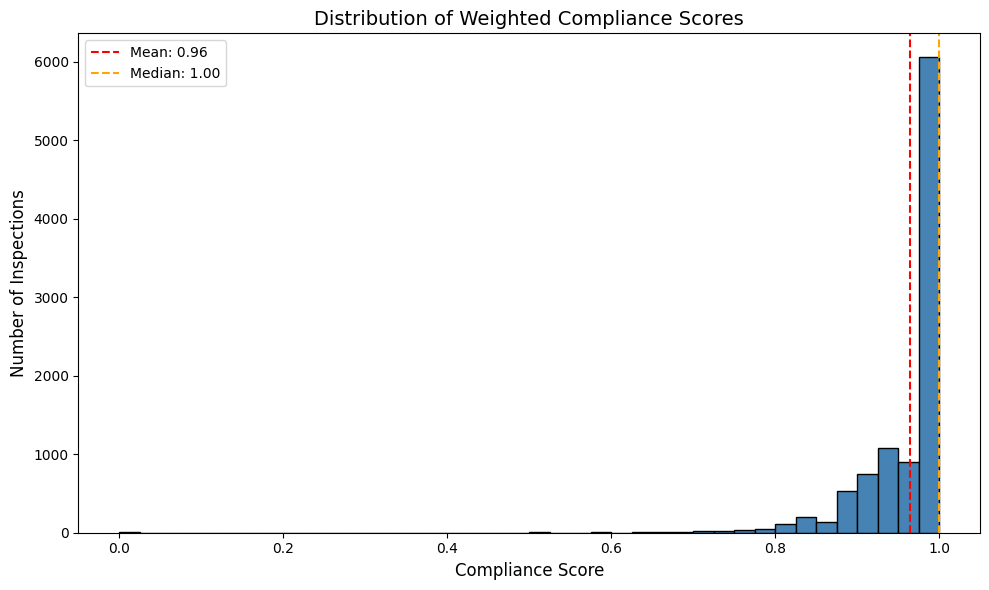

In [17]:
# --- Visualizations ---


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_inspections['compliance_score'], bins=40, edgecolor='black', color='steelblue')

ax.axvline(df_inspections['compliance_score'].mean(), color='red',
           linestyle='--', label=f"Mean: {df_inspections['compliance_score'].mean():.2f}")
ax.axvline(df_inspections['compliance_score'].median(), color='orange',
           linestyle='--', label=f"Median: {df_inspections['compliance_score'].median():.2f}")

ax.set_title('Distribution of Weighted Compliance Scores', fontsize=14)
ax.set_xlabel('Compliance Score', fontsize=12)
ax.set_ylabel('Number of Inspections', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

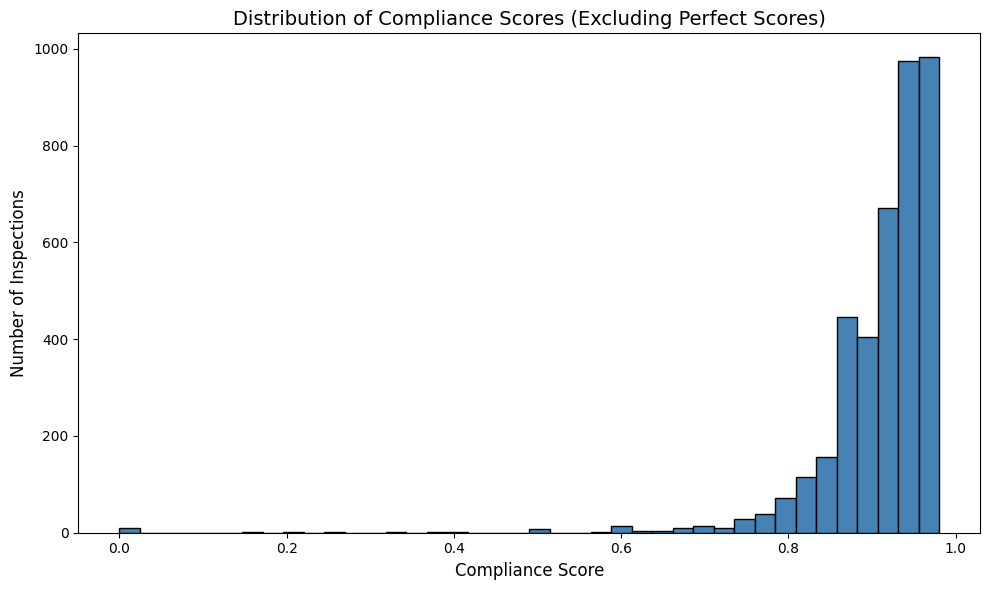

Inspections with perfect score (1.0): 5,981
Inspections below 0.99: 3,971


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

tail = df_inspections[df_inspections['compliance_score'] < 0.99]
ax.hist(tail['compliance_score'], bins=40, edgecolor='black', color='steelblue')

ax.set_title('Distribution of Compliance Scores (Excluding Perfect Scores)', fontsize=14)
ax.set_xlabel('Compliance Score', fontsize=12)
ax.set_ylabel('Number of Inspections', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Inspections with perfect score (1.0): {(df_inspections['compliance_score'] == 1.0).sum():,}")
print(f"Inspections below 0.99: {len(tail):,}")

*Interpret the results. Discuss:*
- *Measures of center and spread*
- *Outliers*
- *Shape of distribution (symmetric, skewed, etc.)*
<br>

Most food establishments in Montgomery County perform very well on inspections, with the typical inspection achieving a perfect or near-perfect weighted compliance score. The distribution is heavily left-skewed with a long thin tail of lower-scoring outliers, suggesting that poor performance is rare but does occur. The mean and median being close to 1.0 confirm the results.
<br><br>
I have two graphs, one with all the data and then one with the perfect scores excluded so we can more easily see the distribution of the results and the outliers.

---
### 4b. Categorical Variable — Descriptive Analysis

**Research Question:** Which zip codes in Montgomery County have the highest and lowest inspection volumes?


In [84]:
# --- Rebuild zip_counts cleanly from scratch ---

# Step 1: Fresh frequency count
zip_counts = df_inspections['zip'].value_counts().reset_index()
zip_counts.columns = ['zip', 'inspection_count']

# Step 2: Get official zip/city reference from shapefile
zip_city_map = zip_boundaries[['ZIPCODE', 'MAIL_CITY']].copy()
zip_city_map.columns = ['zip', 'city_name']
zip_city_map['zip'] = zip_city_map['zip'].astype(str).str.strip()
zip_city_map['city_name'] = zip_city_map['city_name'].str.strip()
zip_city_map = zip_city_map.drop_duplicates(subset='zip')

# Step 3: Filter to valid Montgomery County zips only
valid_zips = zip_city_map['zip'].tolist()
zip_counts = zip_counts[zip_counts['zip'].isin(valid_zips)]

# Step 4: Merge city names once
zip_counts = zip_counts.merge(zip_city_map, on='zip', how='left')

print(f"Official Montgomery County zip codes: {len(zip_city_map)}")
print(f"Zip codes in inspection document: {len(zip_counts)}")
print(zip_counts.columns.tolist())

Official Montgomery County zip codes: 56
Zip codes in inspection document: 47
['zip', 'inspection_count', 'city_name']


In [83]:
print(zip_counts.columns.tolist())

['zip', 'inspection_count', 'city_name_x', 'city_name_y']


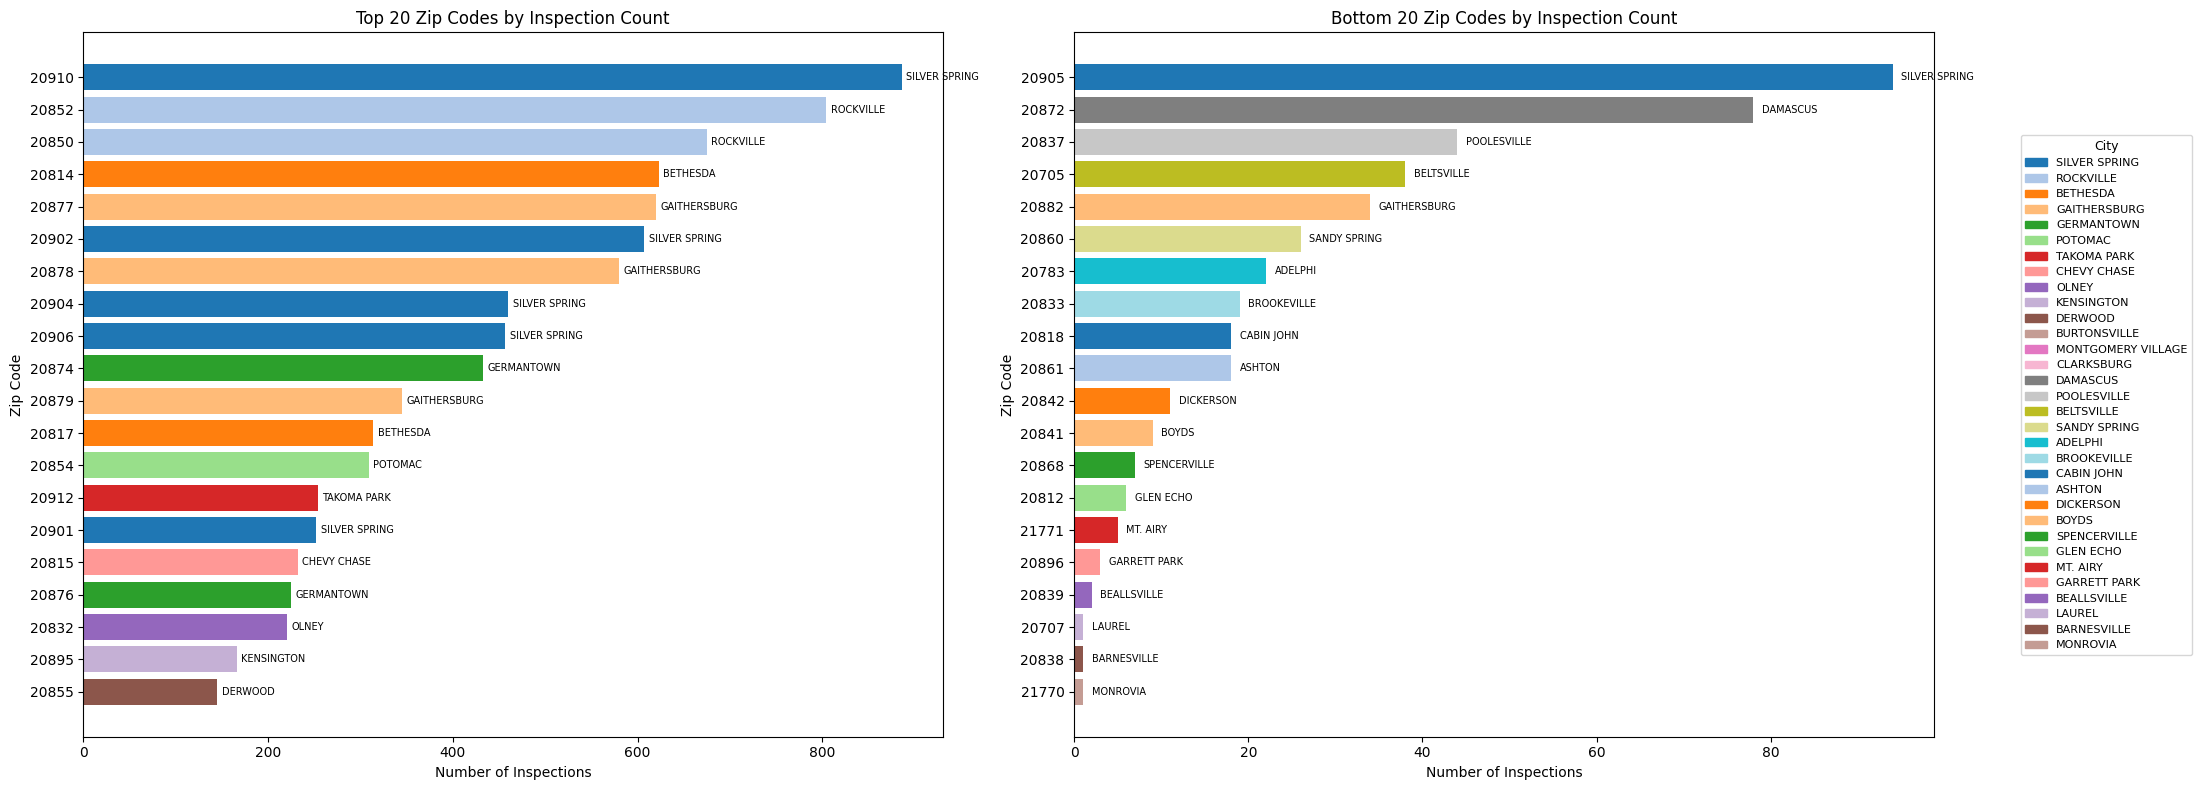

Top 20 Zip Codes by Inspection Count
      zip      city_name  inspection_count
1   20910  SILVER SPRING               886
2   20852      ROCKVILLE               804
3   20850      ROCKVILLE               675
4   20814       BETHESDA               623
5   20877   GAITHERSBURG               620
6   20902  SILVER SPRING               607
7   20878   GAITHERSBURG               580
8   20904  SILVER SPRING               460
9   20906  SILVER SPRING               457
10  20874     GERMANTOWN               433
11  20879   GAITHERSBURG               345
12  20817       BETHESDA               314
13  20854        POTOMAC               309
14  20912    TAKOMA PARK               254
15  20901  SILVER SPRING               252
16  20815    CHEVY CHASE               232
17  20876     GERMANTOWN               225
18  20832          OLNEY               220
19  20895     KENSINGTON               166
20  20855        DERWOOD               145

Bottom 20 Zip Codes by Inspection Count
      zip      city

In [89]:
# --- Assign a color to each unique city ---
cities = zip_counts['city_name'].unique()
tab20_colors = plt.cm.tab20.colors
extended_colors = (tab20_colors * (len(cities) // len(tab20_colors) + 1))[:len(cities)]
color_map = dict(zip(cities, extended_colors))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Top 20 ---
top20 = zip_counts.head(20)
top20_colors = [color_map[c] for c in top20['city_name']]
axes[0].barh(top20['zip'], top20['inspection_count'], color=top20_colors)
axes[0].invert_yaxis()
for i, (count, city) in enumerate(zip(top20['inspection_count'], top20['city_name'])):
    axes[0].text(count + 5, i, city, va='center', fontsize=7)
axes[0].set_title('Top 20 Zip Codes by Inspection Count', fontsize=12)
axes[0].set_xlabel('Number of Inspections', fontsize=10)
axes[0].set_ylabel('Zip Code', fontsize=10)

# --- Bottom 20 ---
bottom20 = zip_counts.tail(20)
bottom20_colors = [color_map[c] for c in bottom20['city_name']]
axes[1].barh(bottom20['zip'], bottom20['inspection_count'], color=bottom20_colors)
axes[1].invert_yaxis()
for i, (count, city) in enumerate(zip(bottom20['inspection_count'], bottom20['city_name'])):
    axes[1].text(count + 1, i, city, va='center', fontsize=7)
axes[1].set_title('Bottom 20 Zip Codes by Inspection Count', fontsize=12)
axes[1].set_xlabel('Number of Inspections', fontsize=10)
axes[1].set_ylabel('Zip Code', fontsize=10)

# --- Shared legend ---
handles = [plt.Rectangle((0,0), 1, 1, color=color_map[c]) for c in cities]
fig.legend(handles, cities, title='City', bbox_to_anchor=(1.01, 0.5),
           loc='center left', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

top20_table = top20[['zip', 'city_name', 'inspection_count']].reset_index(drop=True)
top20_table.index += 1

bottom20_table = bottom20[['zip', 'city_name', 'inspection_count']].reset_index(drop=True)
bottom20_table.index += 1

print("Top 20 Zip Codes by Inspection Count")
print(top20_table.to_string())
print()
print("Bottom 20 Zip Codes by Inspection Count")
print(bottom20_table.to_string())

In [91]:
city_counts = (
    zip_counts.groupby('city_name')
    .agg(
        inspection_count=('inspection_count', 'sum'),
        zip_count=('zip', 'nunique')
    )
    .reset_index()
    .sort_values('inspection_count', ascending=False)
)

print(f"Unique cities: {len(city_counts)}")
print(city_counts.to_string())

Unique cities: 32
             city_name  inspection_count  zip_count
29       SILVER SPRING              2869          7
27           ROCKVILLE              1733          4
15        GAITHERSBURG              1579          4
5             BETHESDA              1038          3
17          GERMANTOWN               658          2
26             POTOMAC               309          1
31         TAKOMA PARK               254          1
10         CHEVY CHASE               232          1
24               OLNEY               220          1
19          KENSINGTON               166          1
13             DERWOOD               145          1
8         BURTONSVILLE               136          1
22  MONTGOMERY VILLAGE               113          1
11          CLARKSBURG               108          1
12            DAMASCUS                78          1
25         POOLESVILLE                44          1
4           BELTSVILLE                38          1
28        SANDY SPRING                26      

*Interpret the results. Discuss:*
- *Definition of levels (what each zip code represents)*
- *Notable patterns or concentrations*

> Zip codes are defined by the USPS and are commonly split based on population growth and urban development. The cities with the largest inspection counts (*Silver Spring*, *Rockville*, *Gaithersburg*, and *Bethesda*) also have the highest number of zip codes, which likely reflects higher population density and greater commercial development in those areas. By contrast, rural communities like Barnesville and Beallsville each have a single zip code and fewer than 3 recorded inspections, consistent with lower commercial food establishment density. This suggests that zip code count may serve as a rough proxy for the volume of food establishments in a given area.

---
### 4c. Relationship Between Variables — Exploratory Analysis

**Research Question:** Do weighted compliance scores differ systematically across zip codes in Montgomery County?

*Why do you expect an association between these two variables?*

In [92]:
# --- Group compliance scores by zip code ---
zip_compliance = (
    df_inspections.groupby('zip')['compliance_score']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_score', 'median': 'median_score', 'count': 'inspection_count'})
    .sort_values('mean_score', ascending=False)
)

# Merge city names
zip_compliance = zip_compliance.merge(zip_city_map, on='zip', how='inner')
zip_compliance = zip_compliance[zip_compliance['zip'].isin(valid_zips)]

print(zip_compliance.to_string())

      zip  mean_score  median_score  inspection_count           city_name
0   20707    1.000000         1.000                 1              LAUREL
1   21770    1.000000         1.000                 1            MONROVIA
2   20896    1.000000         1.000                 3        GARRETT PARK
3   20838    1.000000         1.000                 1         BARNESVILLE
4   20842    0.984545         1.000                11           DICKERSON
5   20905    0.982660         1.000                94       SILVER SPRING
6   21771    0.982000         1.000                 5            MT. AIRY
7   20882    0.981765         1.000                34        GAITHERSBURG
8   20854    0.980259         1.000               309             POTOMAC
9   20861    0.980000         1.000                18              ASHTON
10  20860    0.978846         1.000                26        SANDY SPRING
11  20817    0.978790         1.000               314            BETHESDA
12  20832    0.976545         1.000   

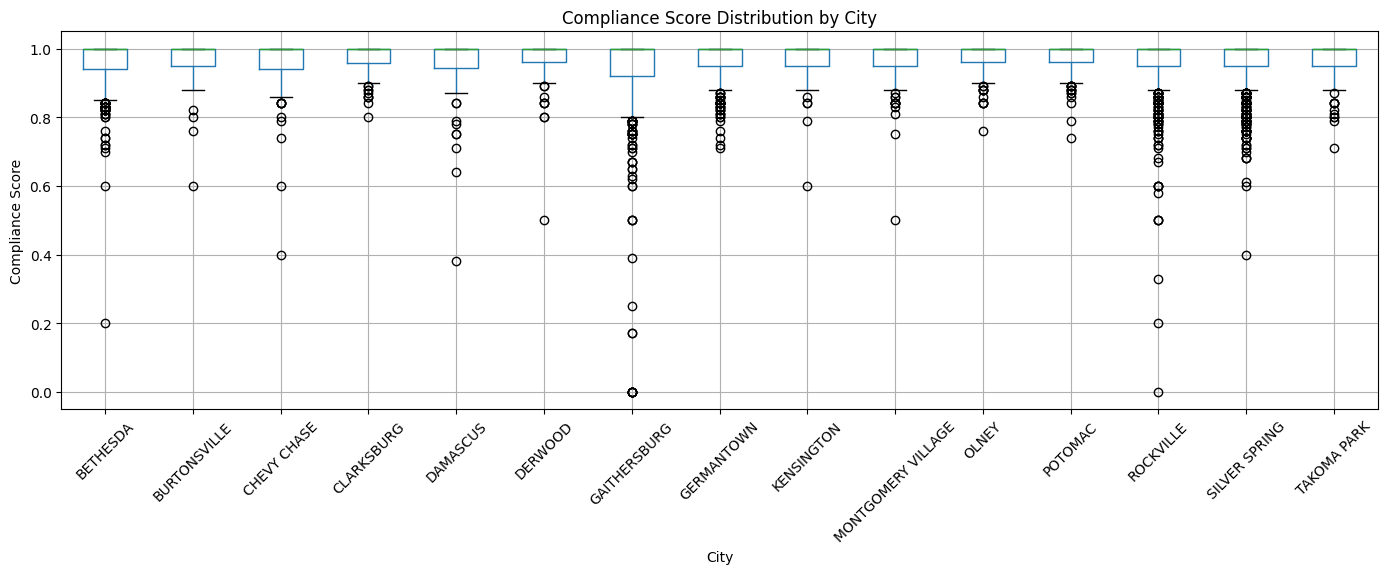

In [93]:
# --- Visualization (e.g., boxplot or grouped bar chart by zip code) ---

# Filter to cities with enough inspections to be meaningful
city_inspection_counts = df_inspections.groupby('zip').size().reset_index(name='n')
df_inspections_mapped = df_inspections.merge(zip_city_map, on='zip', how='inner')
df_inspections_mapped = df_inspections_mapped[df_inspections_mapped['zip'].isin(valid_zips)]

# Filter to cities with at least 50 inspections
city_totals = df_inspections_mapped.groupby('city_name')['compliance_score'].count()
cities_with_enough = city_totals[city_totals >= 50].index

df_plot = df_inspections_mapped[df_inspections_mapped['city_name'].isin(cities_with_enough)]

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.boxplot(column='compliance_score', by='city_name', ax=ax, rot=45)

ax.set_title('Compliance Score Distribution by City', fontsize=12)
ax.set_xlabel('City', fontsize=10)
ax.set_ylabel('Compliance Score', fontsize=10)
plt.suptitle('')
plt.tight_layout()
plt.show()

In [109]:
print(df_inspections['status'].value_counts())
print()
print(df_inspections.groupby('status')['compliance_score'].describe().round(2))

status
Pass                     9471
Fail                      433
Closed                     83
Incomplete                 10
Closed With Complaint       2
Cancelled                   1
Name: count, dtype: int64

                        count  mean   std   min   25%   50%   75%  max
status                                                                
Cancelled                 1.0  1.00   NaN  1.00  1.00  1.00  1.00  1.0
Closed                   82.0  0.96  0.08  0.67  0.96  1.00  1.00  1.0
Closed With Complaint     2.0  0.96  0.06  0.92  0.94  0.96  0.98  1.0
Fail                    424.0  0.90  0.16  0.00  0.86  0.94  1.00  1.0
Incomplete               10.0  0.95  0.09  0.75  0.92  1.00  1.00  1.0
Pass                   9435.0  0.97  0.06  0.00  0.95  1.00  1.00  1.0


*Interpret the results. Discuss:*
- *Whether an association exists*
- *Description of the relationship*
- *Any surprising findings*

> Compliance scores do not appear to differ meaningfully across cities in Montgomery County. While cities with higher inspection volumes such as Gaithersburg and Rockville show greater variability and more low-score outliers, this is likely attributable to sample size rather than genuine geographic differences in food safety compliance. The uniformly high median scores across all cities suggest that compliance is consistently maintained regardless of location.

> While compliance scores are uniformly high across all cities and reflect the findings we saw with the summary statistics, Gaithersburg shows the greatest variability and the lowest individual scores. I am curious if this is driven by a specific zip code within Gaithersburg, or a particular type of establishment.

---
### 4d. Nonparametric Inference — Median Compliance Score

**Research Question:** What is the median weighted compliance score for food establishment inspections in Montgomery County, and how precisely can it be estimated from a random sample?

**Variable:** Compliance Score  
**Method:** Bootstrap resampling (~10% random sample)

In [105]:
# --- Draw ~10% random sample ---

# I just noticed this, but it is extremely weird that there are exactly 10,000 inspections. I have run several cells at the end to investigate, but this is not relavent to our project.

sample_size = int(len(df_inspections) * 0.10)
sample = df_inspections['compliance_score'].dropna().sample(n=sample_size, random_state=42)
print(f"Sample size: {len(sample):,}")
print(f"Sample median: {sample.median():.4f}")
print(f"Sample mean: {sample.mean():.4f}")

Sample size: 1,000
Sample median: 1.0000
Sample mean: 0.9628


In [106]:
# --- Bootstrap the median ---

n_bootstraps = 10000
bootstrap_medians = []

for _ in range(n_bootstraps):
    boot_sample = sample.sample(n=len(sample), replace=True)
    bootstrap_medians.append(boot_sample.median())

bootstrap_medians = np.array(bootstrap_medians)

In [107]:
# --- Compute and display confidence interval ---
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print(f"\nBootstrap Results ({n_bootstraps:,} iterations):")
print(f"Median compliance score: {np.median(bootstrap_medians):.4f}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")


Bootstrap Results (10,000 iterations):
Median compliance score: 1.0000
95% Confidence Interval: (1.0000, 1.0000)


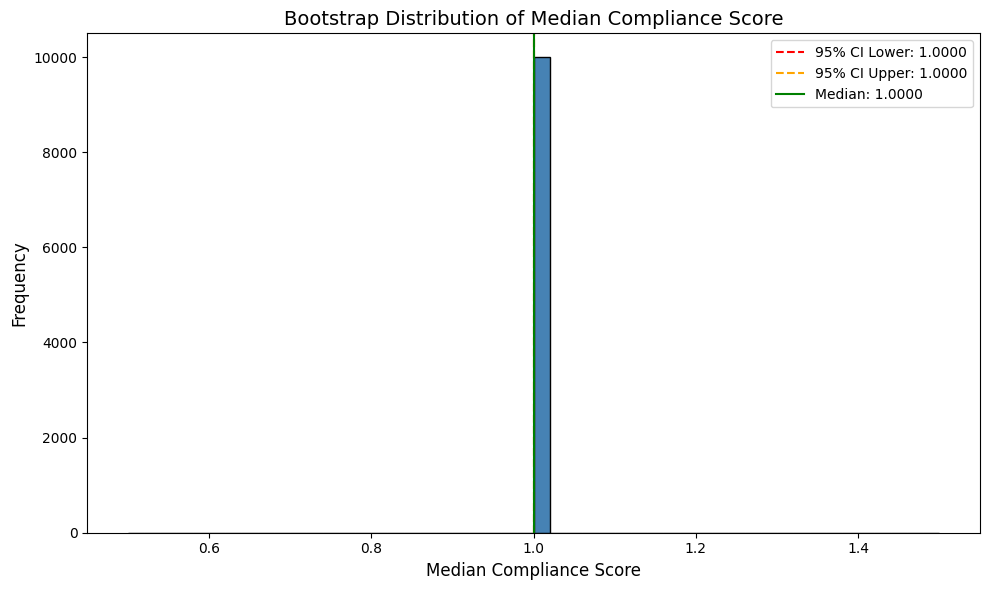

In [108]:
# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bootstrap_medians, bins=50, edgecolor='black', color='steelblue')
ax.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI Lower: {ci_lower:.4f}')
ax.axvline(ci_upper, color='orange', linestyle='--', label=f'95% CI Upper: {ci_upper:.4f}')
ax.axvline(np.median(bootstrap_medians), color='green', linestyle='-',
           label=f'Median: {np.median(bootstrap_medians):.4f}')
ax.set_title('Bootstrap Distribution of Median Compliance Score', fontsize=14)
ax.set_xlabel('Median Compliance Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

*Explain the bootstrap method used and interpret the confidence interval in context:*

> A random sample of 1,000 inspections (~10% of the dataset) was drawn and bootstrap resampling was performed over 10,000 iterations to estimate the median weighted compliance score. The bootstrap median was 1.0000 with a 95% confidence interval of (1.0000, 1.0000), indicating that the true population median is almost certainly exactly 1.0. This result reflects the heavily right-skewed distribution observed earlier — the majority of inspections achieve perfect compliance scores, making the median robust regardless of how the data is resampled. The sample mean of 0.9628 confirms that while violations do occur, they are rare enough to have no effect on the median.

---
## 5. Conclusions / Recommendations

In [110]:
# Passes with very low scores
print("Passes with score <= 0.5:")
print(df_inspections[(df_inspections['status'] == 'Pass') &
                     (df_inspections['compliance_score'] <= 0.5)]
      [['inspection_number', 'business_name', 'zip', 'compliance_score', 'status']])

print("\nFails with perfect score:")
print(df_inspections[(df_inspections['status'] == 'Fail') &
                     (df_inspections['compliance_score'] == 1.0)]
      [['inspection_number', 'business_name', 'zip', 'compliance_score', 'status']])

Passes with score <= 0.5:
     inspection_number                            business_name    zip  \
176            24-0960                         GIANT FOOD #0329  20850   
213            24-1120  LA FONDA PAISA BAKERY AND GROCERY STORE  20878   
252            24-1339               DOWNTOWN CROWN WINE & BEER  20878   
393            24-1912  LA FONDA PAISA BAKERY AND GROCERY STORE  20878   
394            24-1913               LEDO PIZZA - DARNESTOWN RD  20850   
3450          25-10976                              DESHI BAZAR  20877   
5204           25-4202                                COAL FIRE  20878   
7126           25-8734                           TED'S BULLETIN  20878   
7293           25-8999                 CALIFORNIA PIZZA KITCHEN  20878   
8294           26-0343                       PANERA BREAD #3578  20877   
8554           26-0651     WEIBING SHI / KOI, LLC dba KOI SUSHI  20878   
8911           26-1143                            B2J FISH SOUP  20877   
9308        

*Write 1–2 paragraphs summarizing:*
- *Key findings from each analysis*
- *Any trends or associations observed across zip codes*
- *Suggested next steps for further analysis*

> The analysis of Montgomery County HHS food inspection data reveals that food safety compliance is consistently high across the county. The distribution of weighted compliance scores is heavily left-skewed, with a median of 1.0 and a mean of 0.963, indicating that the vast majority of inspections result in perfect or near-perfect scores. Bootstrap resampling confirmed this finding with a 95% confidence interval of (1.0000, 1.0000), suggesting that perfect compliance is the norm rather than the exception. While low-scoring outliers do exist — including a small number of inspections scoring at or near 0.0 that still received a passing status — these represent a small fraction of the overall dataset and warrant further investigation.
<br>

> Geographically, inspection volume is concentrated in the county's most densely developed areas. Silver Spring, Rockville, and Gaithersburg account for the largest share of inspections, which is consistent with their higher number of zip codes and greater commercial development. However, compliance scores do not appear to differ meaningfully across cities or zip codes, suggesting that food safety performance is uniformly maintained regardless of location. Several directions for further analysis would strengthen these findings. First, a time-series analysis could reveal whether compliance trends have improved or declined since July 2024. Second, a closer examination of repeat low-scoring facilities could identify establishments that pose an ongoing public health risk. Third, resolving the outstanding data quality issues with Montgomery County HHS — particularly the prevalence of duplicate records and the absence of raw quantitative measurements — would improve the reliability of any future analysis. Finally, a choropleth map overlaying compliance scores onto the official zip code boundaries would provide a more intuitive geographic visualization of food safety performance across the county.

---
## 6. Extra Inspection for Suspicious 10,000 unique inspection numbers

In [98]:
print(f"Total rows in df: {len(df):,}")
print(f"Total rows in df_clean: {len(df_clean):,}")
print(f"Total rows in df_encoded: {len(df_encoded):,}")
print(f"Total rows in df_inspections: {len(df_inspections):,}")
print(f"Unique inspection numbers in df_encoded: {df_encoded['inspection_number'].nunique():,}")

Total rows in df: 1,127,531
Total rows in df_clean: 16,352
Total rows in df_encoded: 16,352
Total rows in df_inspections: 10,000
Unique inspection numbers in df_encoded: 10,000


In [102]:
for name, dataframe in [('df', df), ('df_clean', df_clean), ('df_encoded', df_encoded)]:
    print(f"--- {name} ---")
    print(f"Total rows: {len(dataframe):,}")
    print(f"Unique inspection numbers: {dataframe['inspection_number'].nunique():,}")
    print(f"Unique registration numbers: {dataframe['registration_number'].nunique():,}")
    print(f"Average rows per inspection: {len(dataframe) / dataframe['inspection_number'].nunique():.1f}")
    print()

--- df ---
Total rows: 1,127,531
Unique inspection numbers: 10,069
Unique registration numbers: 10,771
Average rows per inspection: 112.0

--- df_clean ---
Total rows: 16,352
Unique inspection numbers: 10,000
Unique registration numbers: 10,688
Average rows per inspection: 1.6

--- df_encoded ---
Total rows: 16,352
Unique inspection numbers: 10,000
Unique registration numbers: 10,688
Average rows per inspection: 1.6



In [100]:


# Also check the date range of inspections you actually have
df_inspections['inspection_start_date'] = pd.to_datetime(df_inspections['inspection_start_date'])
print(f"Earliest inspection: {df_inspections['inspection_start_date'].min()}")
print(f"Latest inspection: {df_inspections['inspection_start_date'].max()}")
print(f"Date range: {(df_inspections['inspection_start_date'].max() - df_inspections['inspection_start_date'].min()).days} days")

Earliest inspection: 2024-06-03 00:00:00
Latest inspection: 2026-03-31 00:00:00
Date range: 666 days


In [101]:
print(f"Unique establishments: {df_inspections['registration_number'].nunique():,}")
print(f"Average inspections per establishment: {len(df_inspections) / df_inspections['registration_number'].nunique():.2f}")
print(f"Inspections per month: {len(df_inspections) / (666/30):.0f}")

Unique establishments: 7,674
Average inspections per establishment: 1.30
Inspections per month: 450
